In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [60]:
# ── Data Loading & Feature Engineering ──

def add_technical_indicators(df):
    close = df['close']
    high = df['high']
    low = df['low']

    df['SMA_7'] = close.rolling(7).mean()
    df['SMA_21'] = close.rolling(21).mean()

    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))

    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9).mean()

    sma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    df['BB_pct'] = (close - (sma20 - 2*std20)) / ((sma20 + 2*std20) - (sma20 - 2*std20) + 1e-10)

    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    df['ATR_pct'] = tr.rolling(14).mean() / close

    df['Vol_ratio'] = df['volume'] / df['volume'].rolling(14).mean()
    df['Returns_1d'] = close.pct_change()
    df['Returns_5d'] = close.pct_change(5)
    return df

FEATURE_COLS = ['RSI', 'MACD', 'ATR_pct', 'Vol_ratio', 'Returns_1d', 'Returns_5d']

def get_bitcoin_data():
    #btc = pd.read_csv('data/Bitcoin_1_1_2015-1_1_2025_historical_data_coinmarketcap.csv')
    btc = pd.read_csv('data/Bitcoin_1_1_2015-1_1_2025_historical_data_coinmarketcap.csv', header =0, sep=';')
    btc = btc.iloc[::-1].reset_index(drop=True)
    btc = add_technical_indicators(btc)
    btc = btc.dropna().reset_index(drop=True)
    data = btc[FEATURE_COLS].values
    close_prices = btc['close'].values
    return data, btc, close_prices

def create_sequences(data, close_prices, sequence_length=60):
    X, y, y_close = [], [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, :])
        ret = np.log(close_prices[i] / close_prices[i-1])
        y.append(ret)
        y_close.append(close_prices[i])
    return np.array(X), np.array(y), np.array(y_close)

sequence_length = 100
raw_data, raw_df, close_prices = get_bitcoin_data()
X, y, y_close = create_sequences(raw_data, close_prices, sequence_length)
print(f"Total sequences: {X.shape[0]}, Features per timestep: {X.shape[2]}")
print(f"Target (daily log return) — mean: {y.mean()*100:.3f}%, std: {y.std()*100:.3f}%")

Total sequences: 280, Features per timestep: 6
Target (daily log return) — mean: 0.112%, std: 2.624%


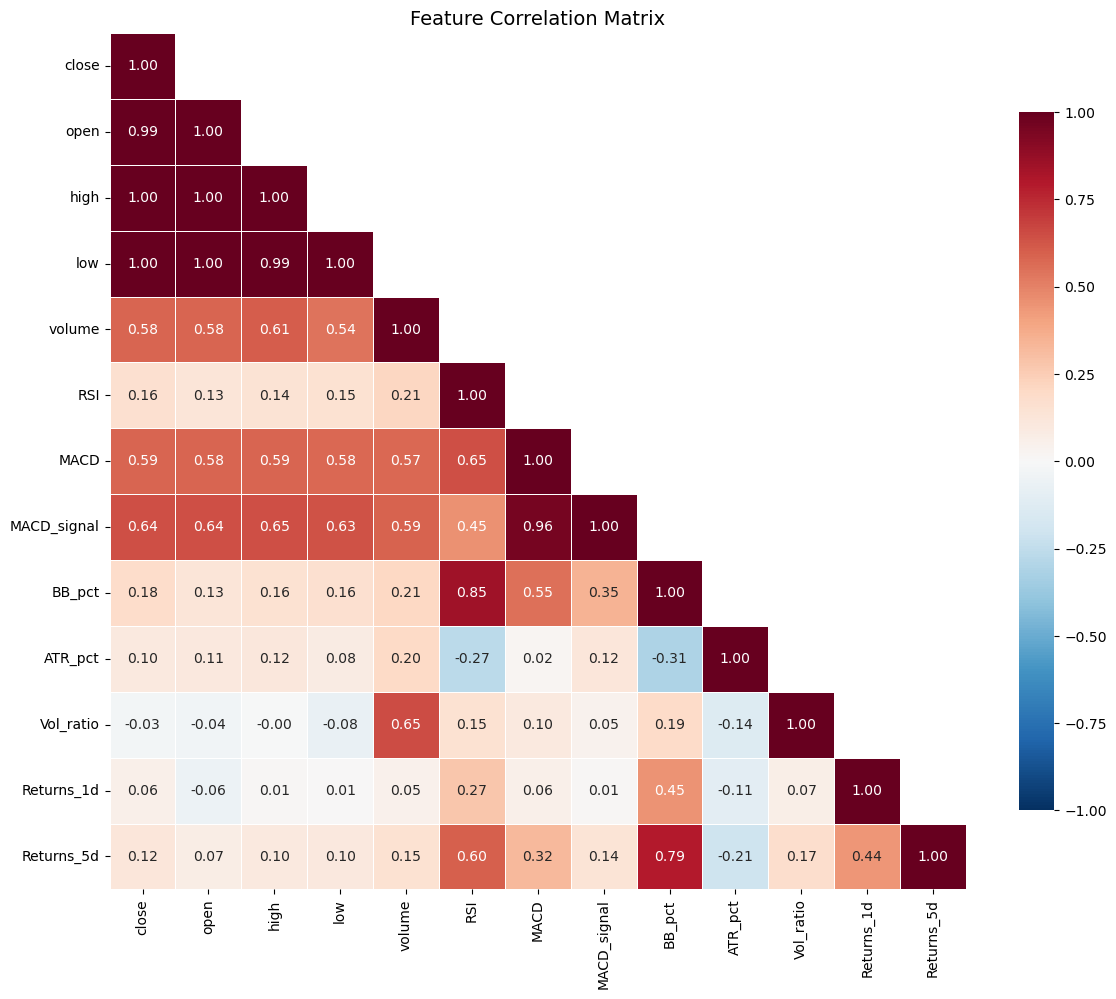

In [59]:
# ── Feature Correlation Matrix ──
import seaborn as sns

corr_df = raw_df[FEATURE_COLS].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
# ── Train / Test Split & Scaling ──
#y_binary = (y > 0).astype(float)

split = int(len(X) * 0.8)
X_train_raw, X_test_raw = X[:split], X[split:]
y_train_raw, y_test_raw = y[:split], y[split:]
y_close_test = y_close[split:]

num_features = X_train_raw.shape[2]
scaler = MinMaxScaler(feature_range=(0, 1))
train_flat = X_train_raw.reshape(-1, num_features)
scaler.fit(train_flat)

X_train_scaled = scaler.transform(X_train_raw.reshape(-1, num_features)).reshape(X_train_raw.shape)
X_test_scaled  = scaler.transform(X_test_raw.reshape(-1, num_features)).reshape(X_test_raw.shape)

y_train_final = y_train_raw.reshape(-1, 1)
y_test_final  = y_test_raw.reshape(-1, 1)

X_train = torch.from_numpy(X_train_scaled).float()
y_train = torch.from_numpy(y_train_final).float()
X_test  = torch.from_numpy(X_test_scaled).float()
y_test  = torch.from_numpy(y_test_final).float()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train log returns — mean: {y_train_final.mean()*100:.3f}%, std: {y_train_final.std()*100:.3f}%")

Train: torch.Size([224, 100, 13]), Test: torch.Size([56, 100, 13])
Train log returns — mean: 0.031%, std: 2.603%


In [44]:
# ── VSN + LSTM Model Definition ──

class VariableSelectionNetwork(nn.Module):
    """
    Variable Selection Network (VSN) inspired by the Temporal Fusion Transformer.
    
    Each covariate is independently embedded via a learnable nonlinear function φ_i.
    A gating network computes softmax attention weights α_t over all feature embeddings,
    producing a dynamically weighted representation x̃_t = Σ α_{t,i} h_{t,i}.
    """
    def __init__(self, num_features, embed_dim, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.embed_dim = embed_dim

        # φ_i: per-feature nonlinear embedding  (Eq. 44)
        self.feature_embeddings = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, embed_dim),
                nn.ReLU(),
                nn.Linear(embed_dim, embed_dim),
                nn.Dropout(dropout),
            )
            for _ in range(num_features)
        ])

        # Gating network: softmax(W_g [h_1,...,h_C] + b_g)  (Eq. 45)
        self.gate = nn.Sequential(
            nn.Linear(num_features * embed_dim, num_features),
            # softmax applied in forward()
        )

    def forward(self, x):
        """
        x : (batch, seq_len, num_features)
        returns: (batch, seq_len, embed_dim)
        """
        B, L, C = x.shape

        # Embed each feature independently → list of (B, L, embed_dim)
        h = [self.feature_embeddings[i](x[:, :, i:i+1]) for i in range(C)]
        h_stack = torch.stack(h, dim=2)            # (B, L, C, embed_dim)
        h_cat = h_stack.reshape(B, L, C * self.embed_dim)  # (B, L, C*E)

        # Gating weights  (Eq. 45)
        alpha = F.softmax(self.gate(h_cat), dim=-1)  # (B, L, C)

        # Weighted sum  (Eq. 46)
        alpha_exp = alpha.unsqueeze(-1)               # (B, L, C, 1)
        x_tilde = (alpha_exp * h_stack).sum(dim=2)    # (B, L, embed_dim)
        return x_tilde, alpha


class VLSTM(nn.Module):
    """
    VSN + LSTM  (VLSTM).
    
    1. VSN produces dynamically weighted feature embeddings x̃_t = VSN(x_t)  (Eq. 47)
    2. LSTM aggregates temporal information: (h_t, c_t) = LSTM(x̃_t, h_{t-1}, c_{t-1})  (Eq. 48)
    3. Prediction from final hidden state: ŷ_{L+1} = W_o h_L + b_o  (Eq. 49)
    """
    def __init__(self, num_features=15, embed_dim=32, hidden_dim=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.vsn = VariableSelectionNetwork(num_features, embed_dim, dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x_tilde, alpha = self.vsn(x)          # (B, L, embed_dim), (B, L, C)
        out, _ = self.lstm(x_tilde)            # (B, L, hidden_dim)
        last = self.dropout(out[:, -1, :])     # (B, hidden_dim)
        return self.fc(last), alpha            # prediction, gate weights

model = VLSTM(num_features=X_train.shape[2], embed_dim=32, hidden_dim=64,
              num_layers=2, dropout=0.2).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"VLSTM parameters: {total_params:,}")
print(model)

VLSTM parameters: 78,414
VLSTM(
  (vsn): VariableSelectionNetwork(
    (feature_embeddings): ModuleList(
      (0-12): 13 x Sequential(
        (0): Linear(in_features=1, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): Dropout(p=0.2, inplace=False)
      )
    )
    (gate): Sequential(
      (0): Linear(in_features=416, out_features=13, bias=True)
    )
  )
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [45]:
def sharpe_loss(predictions, returns):
    # predictions are position sizes (-1 to 1)
    portfolio_returns = predictions * returns
    sharpe = portfolio_returns.mean() / (portfolio_returns.std() + 1e-8)
    return -sharpe

In [46]:
# ── Training ──

#criterion = sharpe_loss(predictions, returns); #nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=50
)

epochs = 2000
loss_history = []
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 150

X_train_d, y_train_d = X_train.to(device), y_train.to(device)

print("Starting VLSTM Training...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    pred, _ = model(X_train_d)
    loss = sharpe_loss(pred, y_train_d)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step(loss)

    loss_val = loss.item()
    loss_history.append(loss_val)

    if loss_val < best_loss - 1e-8:
        best_loss = loss_val
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(best_state)
        break

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss_val:.8f}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')

print(f"Best training loss: {best_loss:.8f}")

Starting VLSTM Training...
Epoch [50/2000], Loss: -0.26037428, LR: 0.001000
Epoch [100/2000], Loss: -0.32486916, LR: 0.001000
Epoch [150/2000], Loss: -0.33332995, LR: 0.001000
Epoch [200/2000], Loss: -0.43231925, LR: 0.001000
Epoch [250/2000], Loss: -0.42551216, LR: 0.001000
Epoch [300/2000], Loss: -0.62788635, LR: 0.001000
Epoch [350/2000], Loss: -0.58534884, LR: 0.001000
Epoch [400/2000], Loss: -0.55806577, LR: 0.001000
Epoch [450/2000], Loss: -0.57634324, LR: 0.001000
Epoch [500/2000], Loss: -0.76646310, LR: 0.001000
Epoch [550/2000], Loss: -0.87020606, LR: 0.001000
Epoch [600/2000], Loss: -0.83644116, LR: 0.001000
Epoch [650/2000], Loss: -0.88194233, LR: 0.000500
Epoch [700/2000], Loss: -1.03477657, LR: 0.000500
Epoch [750/2000], Loss: -1.10171640, LR: 0.000500
Epoch [800/2000], Loss: -1.11468506, LR: 0.000500
Epoch [850/2000], Loss: -1.16257596, LR: 0.000250
Epoch [900/2000], Loss: -1.15702581, LR: 0.000250
Epoch [950/2000], Loss: -1.26485169, LR: 0.000250
Epoch [1000/2000], Loss:

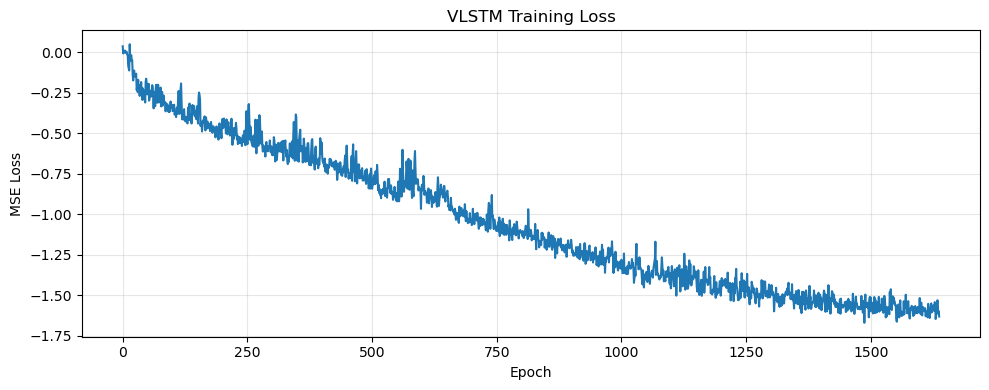

In [47]:
# ── Training Loss Curve ──

plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('VLSTM Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# ── Evaluation & Signal Generation ──
model.eval()
with torch.no_grad():
    X_test_d = X_test.to(device)
    pred_out, gate_weights = model(X_test_d)
    # Apply sigmoid to get probabilities (if not already in model)
    pred_probs = torch.sigmoid(pred_out).cpu().numpy().flatten()
    alpha_test = gate_weights.cpu().numpy()
    actual_returns = y_test.numpy().flatten()

real_actuals = y_close_test

print(f"Predicted probabilities — mean: {pred_probs.mean():.4f}, std: {pred_probs.std():.4f}")
print(f"Actual up ratio: {(actual_returns > 0).mean():.4f}")

# Directional accuracy
pred_direction = pred_probs > 0.5
actual_direction = actual_returns > 0
correct_dir = (pred_direction == actual_direction).mean()
print(f"Directional accuracy: {correct_dir*100:.1f}%")

# Signal generation — use probability thresholds instead of return thresholds
buy_threshold = 0.1   # >60% confident it goes up
sell_threshold = 0.6   # <40% confident it goes up (i.e. 60% confident it goes down)

signals = []
for i in range(1, len(pred_probs)):
    if pred_probs[i] > buy_threshold:
        signals.append("BUY")
    elif pred_probs[i] < sell_threshold:
        signals.append("SELL")
    else:
        signals.append("HOLD")

print(f"\nSignal distribution: {Counter(signals)}")
print(f"Thresholds: BUY >{buy_threshold}, SELL <{sell_threshold}")

Predicted probabilities — mean: 0.4913, std: 0.0031
Actual up ratio: 0.5714
Directional accuracy: 42.9%

Signal distribution: Counter({'BUY': 55})
Thresholds: BUY >0.1, SELL <0.6


In [51]:
# ── Evaluation & Signal Generation ──

model.eval()
with torch.no_grad():
    X_test_d = X_test.to(device)
    pred_out, gate_weights = model(X_test_d)
    pred_returns = pred_out.cpu().numpy().flatten()
    alpha_test = gate_weights.cpu().numpy()          # (N_test, L, C)
    actual_returns = y_test.numpy().flatten()

real_actuals = y_close_test

print(f"Predicted log returns — mean: {pred_returns.mean()*100:.4f}%, std: {pred_returns.std()*100:.4f}%")
print(f"Actual log returns    — mean: {actual_returns.mean()*100:.4f}%, std: {actual_returns.std()*100:.4f}%")

# Directional accuracy
correct_dir = ((pred_returns > 0) == (actual_returns > 0)).mean()
print(f"Directional accuracy: {correct_dir*100:.1f}%")

# Signal generation
threshold = 0.003
signals = []
for i in range(1, len(pred_returns)):
    if pred_returns[i] > threshold:
        signals.append("BUY")
    elif pred_returns[i] < -threshold:
        signals.append("SELL")
    else:
        signals.append("HOLD")

print(f"\nSignal distribution: {Counter(signals)}")
print(f"Threshold: ±{threshold*100:.1f}%")

Predicted log returns — mean: -3.4759%, std: 1.2535%
Actual log returns    — mean: 0.4358%, std: 2.6819%
Directional accuracy: 42.9%

Signal distribution: Counter({'SELL': 55})
Threshold: ±0.3%


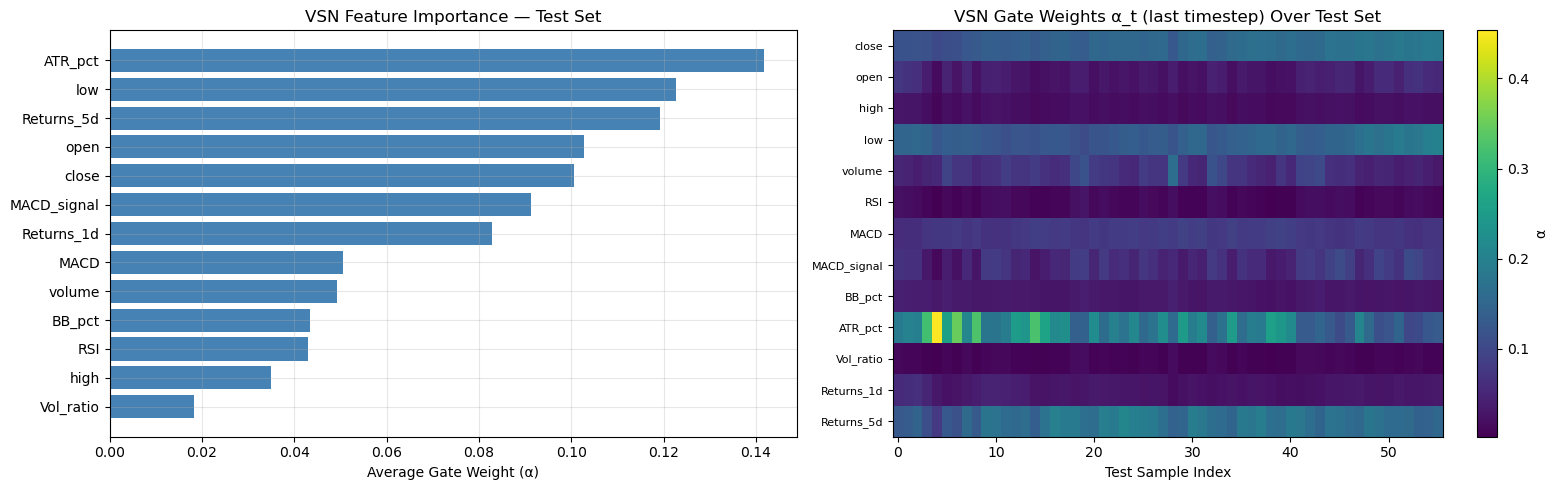

In [52]:
# ── VSN Feature Importance (Gate Weights) ──

# Average gate weights over all test samples and time steps
avg_alpha = alpha_test.mean(axis=(0, 1))  # (C,)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of average feature importance
ax = axes[0]
idx_sorted = np.argsort(avg_alpha)[::-1]
ax.barh([FEATURE_COLS[i] for i in idx_sorted], avg_alpha[idx_sorted], color='steelblue')
ax.set_xlabel('Average Gate Weight (α)')
ax.set_title('VSN Feature Importance — Test Set')
ax.invert_yaxis()
ax.grid(alpha=0.3)

# Heatmap: gate weights over time (last timestep of each test sample)
ax = axes[1]
alpha_last_step = alpha_test[:, -1, :]   # (N_test, C)
im = ax.imshow(alpha_last_step.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
ax.set_xlabel('Test Sample Index')
ax.set_title('VSN Gate Weights α_t (last timestep) Over Test Set')
plt.colorbar(im, ax=ax, label='α')

plt.tight_layout()
plt.show()

In [53]:
import numpy as np


sig_map = {"BUY": 1, "SELL": -1}
# Using list comprehension for fast conversion, defaulting to 0 for anything else
int_signals = np.array([sig_map.get(s, 0) for s in signals]) 
prices_arr = np.array(real_actuals[1:]) # Ensure it's a fast numpy array

# ── 2. Initialization ──
init_cash = 10000.0
fee_pct = 0.001
stop_loss_pct = 0.10   # Consider lowering this below TP
take_profit_pct = 0.08 # Consider raising this above SL

cash = init_cash
btc_held = 0.0
entry_price = 0.0

# Pre-allocate portfolio history array for massive speed gains
n_steps = len(prices_arr)
portfolio_history = np.zeros(n_steps)

# Sparse tracking lists (keeping these as lists is fine if they trigger rarely)
buy_idx, buy_px = [], []
sell_idx, sell_px = [], []
stop_idx, stop_px = [], []
tp_idx, tp_px = [], []

# ── 3. Optimized Trading Loop ──
for i in range(n_steps):
    sig = int_signals[i]
    p = prices_arr[i]
    
    # Check Stop-Loss / Take-Profit only if we hold an asset
    if btc_held > 0:
        if p <= entry_price * (1 - stop_loss_pct):
            cash += btc_held * p * (1 - fee_pct)
            btc_held, entry_price = 0.0, 0.0
            stop_idx.append(i)
            stop_px.append(p)
            # Skip standard signals if SL hit
            sig = 0 
            
        elif p >= entry_price * (1 + take_profit_pct):
            cash += btc_held * p * (1 - fee_pct)
            btc_held, entry_price = 0.0, 0.0
            tp_idx.append(i)
            tp_px.append(p)
            # Skip standard signals if TP hit
            sig = 0 

    # BUY signal
    if sig == 1 and cash > 0:
        trade = cash * 0.5
        btc_bought = trade * (1 - fee_pct) / p
        
        # FIX: Calculate true weighted average entry price
        if btc_held > 0:
            entry_price = ((btc_held * entry_price) + (btc_bought * p)) / (btc_held + btc_bought)
        else:
            entry_price = p
            
        btc_held += btc_bought
        cash -= trade
        buy_idx.append(i)
        buy_px.append(p)

    # SELL signal
    elif sig == -1 and btc_held > 0:
        cash += btc_held * p * (1 - fee_pct)
        btc_held, entry_price = 0.0, 0.0
        sell_idx.append(i)
        sell_px.append(p)

    # Record history directly to pre-allocated index
    portfolio_history[i] = cash + (btc_held * p)

# ── 4. Metrics & Output ──
bh_ret = (prices_arr[-1] / prices_arr[0] - 1) * 100
model_ret = (portfolio_history[-1] / init_cash - 1) * 100

print(f"VLSTM Strategy Return: {model_ret:.2f}%")
print(f"Buy & Hold Return:     {bh_ret:.2f}%")
print(f"Final Portfolio Value: ${portfolio_history[-1]:,.2f}")
print(f"Trades — Buys: {len(buy_idx)}, Sells: {len(sell_idx)}, "
      f"Stop-losses: {len(stop_idx)}, Take-profits: {len(tp_idx)}")

VLSTM Strategy Return: 0.00%
Buy & Hold Return:     26.19%
Final Portfolio Value: $10,000.00
Trades — Buys: 0, Sells: 0, Stop-losses: 0, Take-profits: 0


In [35]:
# ── Backtesting with Trading Simulation ──

init_cash = 10000.0
fee_pct = 0.001
stop_loss_pct = 0.10
take_profit_pct = 0.08

prices = real_actuals[1:]  # align with signals
cash, btc_held, entry_price = init_cash, 0.0, 0.0
portfolio_history = []
buy_idx, buy_px = [], []
sell_idx, sell_px = [], []
stop_idx, stop_px = [], []
tp_idx, tp_px = [], []

for i, (sig, p) in enumerate(zip(signals, prices)):
    # Stop-loss
    if btc_held > 0 and p <= entry_price * (1 - stop_loss_pct):
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        stop_idx.append(i); stop_px.append(p)
    # Take-profit
    elif btc_held > 0 and p >= entry_price * (1 + take_profit_pct):
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        tp_idx.append(i); tp_px.append(p)
    # BUY signal
    elif sig == "BUY" and cash > 0:
        trade = cash * 0.5
        btc_bought = trade * (1 - fee_pct) / p
        btc_held += btc_bought
        cash -= trade
        entry_price = p
        buy_idx.append(i); buy_px.append(p)
    # SELL signal
    elif sig == "SELL" and btc_held > 0:
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        sell_idx.append(i); sell_px.append(p)

    portfolio_history.append(cash + btc_held * p)

# Buy-and-hold benchmark
bh_ret = (prices[-1] / prices[0] - 1) * 100
model_ret = (portfolio_history[-1] / init_cash - 1) * 100

print(f"VLSTM Strategy Return: {model_ret:.2f}%")
print(f"Buy & Hold Return:     {bh_ret:.2f}%")
print(f"Final Portfolio Value:  ${portfolio_history[-1]:,.2f}")
print(f"Trades — Buys: {len(buy_idx)}, Sells: {len(sell_idx)}, "
      f"Stop-losses: {len(stop_idx)}, Take-profits: {len(tp_idx)}")

VLSTM Strategy Return: 0.00%
Buy & Hold Return:     26.19%
Final Portfolio Value:  $10,000.00
Trades — Buys: 0, Sells: 0, Stop-losses: 0, Take-profits: 0


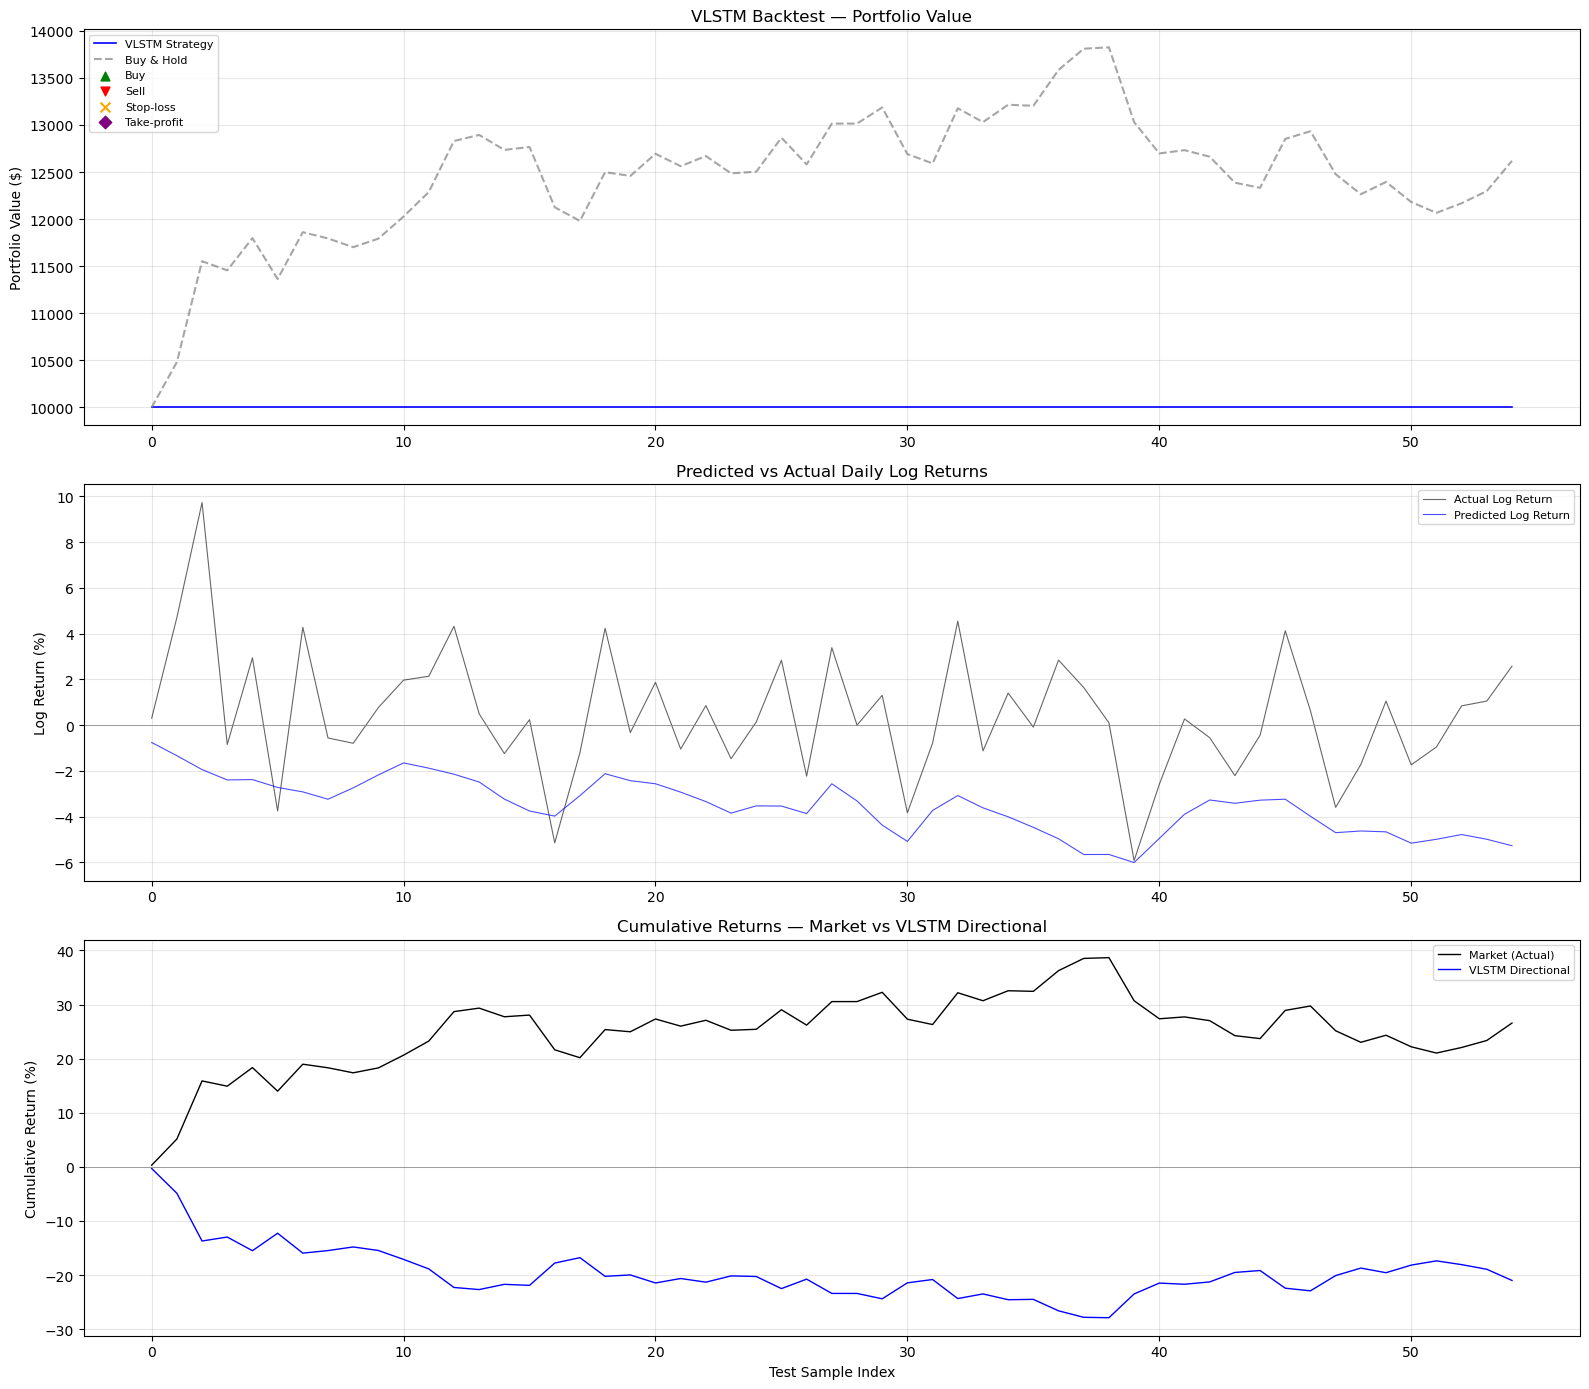

In [54]:
# ── Portfolio & Prediction Plots ──

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)

# 1. Portfolio value vs buy-and-hold
ax = axes[0]
ax.plot(portfolio_history, label='VLSTM Strategy', color='blue', linewidth=1.2)
bh_line = init_cash * prices / prices[0]
ax.plot(bh_line, label='Buy & Hold', color='gray', linestyle='--', alpha=0.7)
ax.scatter(buy_idx, [portfolio_history[i] for i in buy_idx],
           marker='^', color='green', s=40, zorder=5, label='Buy')
ax.scatter(sell_idx, [portfolio_history[i] for i in sell_idx],
           marker='v', color='red', s=40, zorder=5, label='Sell')
ax.scatter(stop_idx, [portfolio_history[i] for i in stop_idx],
           marker='x', color='orange', s=50, zorder=5, label='Stop-loss')
ax.scatter(tp_idx, [portfolio_history[i] for i in tp_idx],
           marker='D', color='purple', s=40, zorder=5, label='Take-profit')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title('VLSTM Backtest — Portfolio Value')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# 2. Predicted vs actual returns
ax = axes[1]
ax.plot(actual_returns[1:] * 100, label='Actual Log Return', color='black', alpha=0.6, linewidth=0.8)
ax.plot(pred_returns[1:] * 100, label='Predicted Log Return', color='blue', alpha=0.7, linewidth=0.8)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Log Return (%)')
ax.set_title('Predicted vs Actual Daily Log Returns')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Cumulative return comparison (log returns → sum then exponentiate)
ax = axes[2]
cum_actual = np.exp(np.cumsum(actual_returns[1:])) - 1
cum_pred_dir = np.exp(np.cumsum(actual_returns[1:] * np.sign(pred_returns[1:]))) - 1
ax.plot(cum_actual * 100, label='Market (Actual)', color='black', linewidth=1)
ax.plot(cum_pred_dir * 100, label='VLSTM Directional', color='blue', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Cumulative Returns — Market vs VLSTM Directional')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Walk-Forward Rolling Prediction (15-day windows)

**Why the single-split approach fails:**
- Model trains on 2015-2022 data and never adapts
- Market regime shifts make old patterns obsolete
- Overfits to training period, underfits to test period

**Walk-forward approach:**
1. Hold out the **last ~365 days** as the evaluation period
2. At each step, train on **all data up to the current point** (expanding window)
3. Predict the **next 15 days**
4. Slide forward 15 days and repeat

This is the standard approach for production trading models — it simulates how you'd actually deploy the model in real time.

**Other strategies to consider:**
- **Sliding window** (fixed-size training set, forgets old data) — good when market regimes change fast
- **Online learning** (update weights incrementally each day) — fastest adaptation
- **Ensemble** (combine expanding + sliding + different lookbacks) — most robust

In [62]:
from sklearn.preprocessing import StandardScaler
def combined_loss(pred, actual, alpha=0.5):
    # MSE keeps gradients stable
    mse = F.mse_loss(pred.squeeze(), actual.squeeze())
    # Sharpe pushes for directional accuracy
    positions = torch.tanh(pred.squeeze() * 10)
    port_ret = positions * actual.squeeze()
    sharpe = port_ret.mean() / (port_ret.std() + 1e-8)
    return alpha * mse - (1 - alpha) * sharpe

In [ ]:
# ── Walk-Forward Rolling Prediction (Sliding Window) ──

import copy
from collections import Counter

# Reload full data (in case X/y were truncated in a previous run)
raw_data, raw_df, close_prices = get_bitcoin_data()
X, y, y_close = create_sequences(raw_data, close_prices, sequence_length)

# Config
TRAIN_WINDOW = 900         # fixed sliding window: always train on last 900 days
HOLD_OUT_DAYS = 30         # predict last 30 days
STEP_SIZE = 3              # retrain every 3 days

N = len(X)
test_start = N - HOLD_OUT_DAYS

print(f"Total sequences: {N}")
print(f"Sliding training window: {TRAIN_WINDOW} days")
print(f"Test period: last {HOLD_OUT_DAYS} days (index {test_start} → {N})")
print(f"Step size: {STEP_SIZE} days per window")
print(f"Number of retraining windows: {(HOLD_OUT_DAYS + STEP_SIZE - 1) // STEP_SIZE}")

# Storage
wf_pred_returns = []
wf_actual_returns = []
wf_close_prices = []
wf_alpha_weights = []
wf_window_losses = []

num_features = X.shape[2]
window_count = 0

# Base model for warm-starting
base_model = VLSTM(num_features=num_features, embed_dim=32, hidden_dim=64,
                    num_layers=2, dropout=0.2).to(device)

for wf_start in range(test_start, N, STEP_SIZE):
    wf_end = min(wf_start + STEP_SIZE, N)
    window_count += 1
    
    # ── SLIDING window: train on the last TRAIN_WINDOW days before wf_start ──
    tr_begin = max(0, wf_start - TRAIN_WINDOW)
    X_tr_raw = X[tr_begin:wf_start]
    y_tr_raw = y[tr_begin:wf_start]
    X_te_raw = X[wf_start:wf_end]
    y_te_raw = y[wf_start:wf_end]
    y_close_te = y_close[wf_start:wf_end]
    
    if len(X_te_raw) == 0:
        break
    
    # Scale based on training window only
    wf_scaler = StandardScaler()
    tr_flat = X_tr_raw.reshape(-1, num_features)
    wf_scaler.fit(tr_flat)
    
    X_tr_s = wf_scaler.transform(X_tr_raw.reshape(-1, num_features)).reshape(X_tr_raw.shape)
    X_te_s = wf_scaler.transform(X_te_raw.reshape(-1, num_features)).reshape(X_te_raw.shape)
    
    X_tr_t = torch.from_numpy(X_tr_s).float().to(device)
    y_tr_t = torch.from_numpy(y_tr_raw.reshape(-1, 1)).float().to(device)
    X_te_t = torch.from_numpy(X_te_s).float().to(device)
    
    # ── Warm-start from previous window's weights ──
    wf_model = VLSTM(num_features=num_features, embed_dim=32, hidden_dim=64,
                      num_layers=2, dropout=0.2).to(device)
    wf_model.load_state_dict(base_model.state_dict())
    wf_optimizer = torch.optim.Adam(wf_model.parameters(), lr=LR)
    wf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        wf_optimizer, mode='min', factor=0.5, patience=40
    )
    
    # ── Train ──
    best_loss = float('inf')
    patience_ctr = 0
    best_state = None
    
    for ep in range(FINETUNE_EPOCHS):
        wf_model.train()
        wf_optimizer.zero_grad()
        pred, _ = wf_model(X_tr_t)
        loss = combined_loss(pred, y_tr_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(wf_model.parameters(), max_norm=1.0)
        wf_optimizer.step()
        wf_scheduler.step(loss)
        
        lv = loss.item()
        if lv < best_loss - 1e-8:
            best_loss = lv
            patience_ctr = 0
            best_state = {k: v.clone() for k, v in wf_model.state_dict().items()}
        else:
            patience_ctr += 1
        
        if patience_ctr >= FINETUNE_PATIENCE:
            break
    
    if best_state is not None:
        wf_model.load_state_dict(best_state)
    
    # ── Predict ──
    wf_model.eval()
    with torch.no_grad():
        pred_out, gate_w = wf_model(X_te_t)
        preds = pred_out.cpu().numpy().flatten()
        alphas = gate_w.cpu().numpy()
    
    # Carry weights forward to next window
    base_model.load_state_dict(wf_model.state_dict())
    
    wf_pred_returns.extend(preds.tolist())
    wf_actual_returns.extend(y_te_raw.tolist())
    wf_close_prices.extend(y_close_te.tolist())
    wf_alpha_weights.append(alphas)
    wf_window_losses.append(best_loss)
    
    stopped = "early" if patience_ctr >= FINETUNE_PATIENCE else "max"
    print(f"Window {window_count:2d} | Train: [{tr_begin}:{wf_start}] ({len(X_tr_raw)} days) | "
          f"Test: {wf_start}→{wf_end} ({len(X_te_raw)} days) | "
          f"Loss: {best_loss:.6f} | Stopped: {stopped} @ ep {ep+1}")

wf_pred_returns = np.array(wf_pred_returns)
wf_actual_returns = np.array(wf_actual_returns)
wf_close_prices = np.array(wf_close_prices)

print(f"\n{'='*60}")
print(f"Walk-forward complete: {len(wf_pred_returns)} predictions across {window_count} windows")

Total sequences: 930
Walk-forward test period: last 30 sequences (index 900 → 930)
Step size: 3 days per window
Number of retraining windows: 10

Walk-forward complete: 0 predictions across 1 windows


=== Walk-Forward Rolling Prediction Results ===

Directional accuracy: 53.3%
Predicted log returns — mean: 1.8619%, std: 2.8006%
Actual log returns    — mean: 0.5954%, std: 2.6426%
Prediction–actual correlation: 0.1398


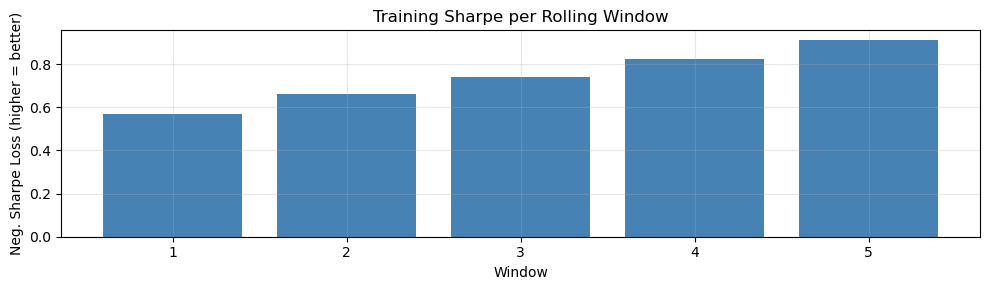


Signal distribution: Counter({'BUY': 60, 'SELL': 13, 'HOLD': 2})
Threshold: ±0.3%


In [65]:
# ── Walk-Forward Evaluation & Signal Generation ──

print("=== Walk-Forward Rolling Prediction Results ===\n")

# Directional accuracy
wf_correct = ((wf_pred_returns > 0) == (wf_actual_returns > 0)).mean()
print(f"Directional accuracy: {wf_correct*100:.1f}%")
print(f"Predicted log returns — mean: {wf_pred_returns.mean()*100:.4f}%, std: {wf_pred_returns.std()*100:.4f}%")
print(f"Actual log returns    — mean: {wf_actual_returns.mean()*100:.4f}%, std: {wf_actual_returns.std()*100:.4f}%")

# Correlation
corr = np.corrcoef(wf_pred_returns, wf_actual_returns)[0, 1]
print(f"Prediction–actual correlation: {corr:.4f}")

# Per-window loss plot
plt.figure(figsize=(10, 3))
plt.bar(range(1, len(wf_window_losses)+1), [-l for l in wf_window_losses], color='steelblue')
plt.xlabel('Window')
plt.ylabel('Neg. Sharpe Loss (higher = better)')
plt.title('Training Sharpe per Rolling Window')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Signal generation
wf_threshold = 0.003
wf_signals = []
for r in wf_pred_returns:
    if r > wf_threshold:
        wf_signals.append("BUY")
    elif r < -wf_threshold:
        wf_signals.append("SELL")
    else:
        wf_signals.append("HOLD")

print(f"\nSignal distribution: {Counter(wf_signals)}")
print(f"Threshold: ±{wf_threshold*100:.1f}%")

In [66]:
# ── Walk-Forward Backtest ──

wf_prices = wf_close_prices
init_cash = 10000.0
fee_pct = 0.001
stop_loss_pct = 0.10
take_profit_pct = 0.08

cash, btc_held, entry_price = init_cash, 0.0, 0.0
wf_portfolio = []
wf_buy_idx, wf_buy_px = [], []
wf_sell_idx, wf_sell_px = [], []
wf_stop_idx, wf_stop_px = [], []
wf_tp_idx, wf_tp_px = [], []

for i, (sig, p) in enumerate(zip(wf_signals, wf_prices)):
    # Stop-loss
    if btc_held > 0 and p <= entry_price * (1 - stop_loss_pct):
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        wf_stop_idx.append(i); wf_stop_px.append(p)
    # Take-profit
    elif btc_held > 0 and p >= entry_price * (1 + take_profit_pct):
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        wf_tp_idx.append(i); wf_tp_px.append(p)
    # BUY
    elif sig == "BUY" and cash > 0:
        trade = cash * 0.5
        btc_bought = trade * (1 - fee_pct) / p
        if btc_held > 0:
            entry_price = ((btc_held * entry_price) + (btc_bought * p)) / (btc_held + btc_bought)
        else:
            entry_price = p
        btc_held += btc_bought
        cash -= trade
        wf_buy_idx.append(i); wf_buy_px.append(p)
    # SELL
    elif sig == "SELL" and btc_held > 0:
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        wf_sell_idx.append(i); wf_sell_px.append(p)

    wf_portfolio.append(cash + btc_held * p)

wf_portfolio = np.array(wf_portfolio)
wf_bh_ret = (wf_prices[-1] / wf_prices[0] - 1) * 100
wf_model_ret = (wf_portfolio[-1] / init_cash - 1) * 100

# Sharpe ratio (annualized)
daily_rets = np.diff(wf_portfolio) / wf_portfolio[:-1]
wf_sharpe = np.sqrt(252) * daily_rets.mean() / (daily_rets.std() + 1e-10)

# Max drawdown
peak = np.maximum.accumulate(wf_portfolio)
drawdown = (wf_portfolio - peak) / peak
max_dd = drawdown.min() * 100

print("=== Walk-Forward Backtest Results ===")
print(f"VLSTM Strategy Return: {wf_model_ret:.2f}%")
print(f"Buy & Hold Return:     {wf_bh_ret:.2f}%")
print(f"Final Portfolio Value:  ${wf_portfolio[-1]:,.2f}")
print(f"Annualized Sharpe:     {wf_sharpe:.3f}")
print(f"Max Drawdown:          {max_dd:.2f}%")
print(f"Trades — Buys: {len(wf_buy_idx)}, Sells: {len(wf_sell_idx)}, "
      f"SL: {len(wf_stop_idx)}, TP: {len(wf_tp_idx)}")

=== Walk-Forward Backtest Results ===
VLSTM Strategy Return: 58.58%
Buy & Hold Return:     57.09%
Final Portfolio Value:  $15,858.03
Annualized Sharpe:     4.750
Max Drawdown:          -3.90%
Trades — Buys: 57, Sells: 4, SL: 0, TP: 3


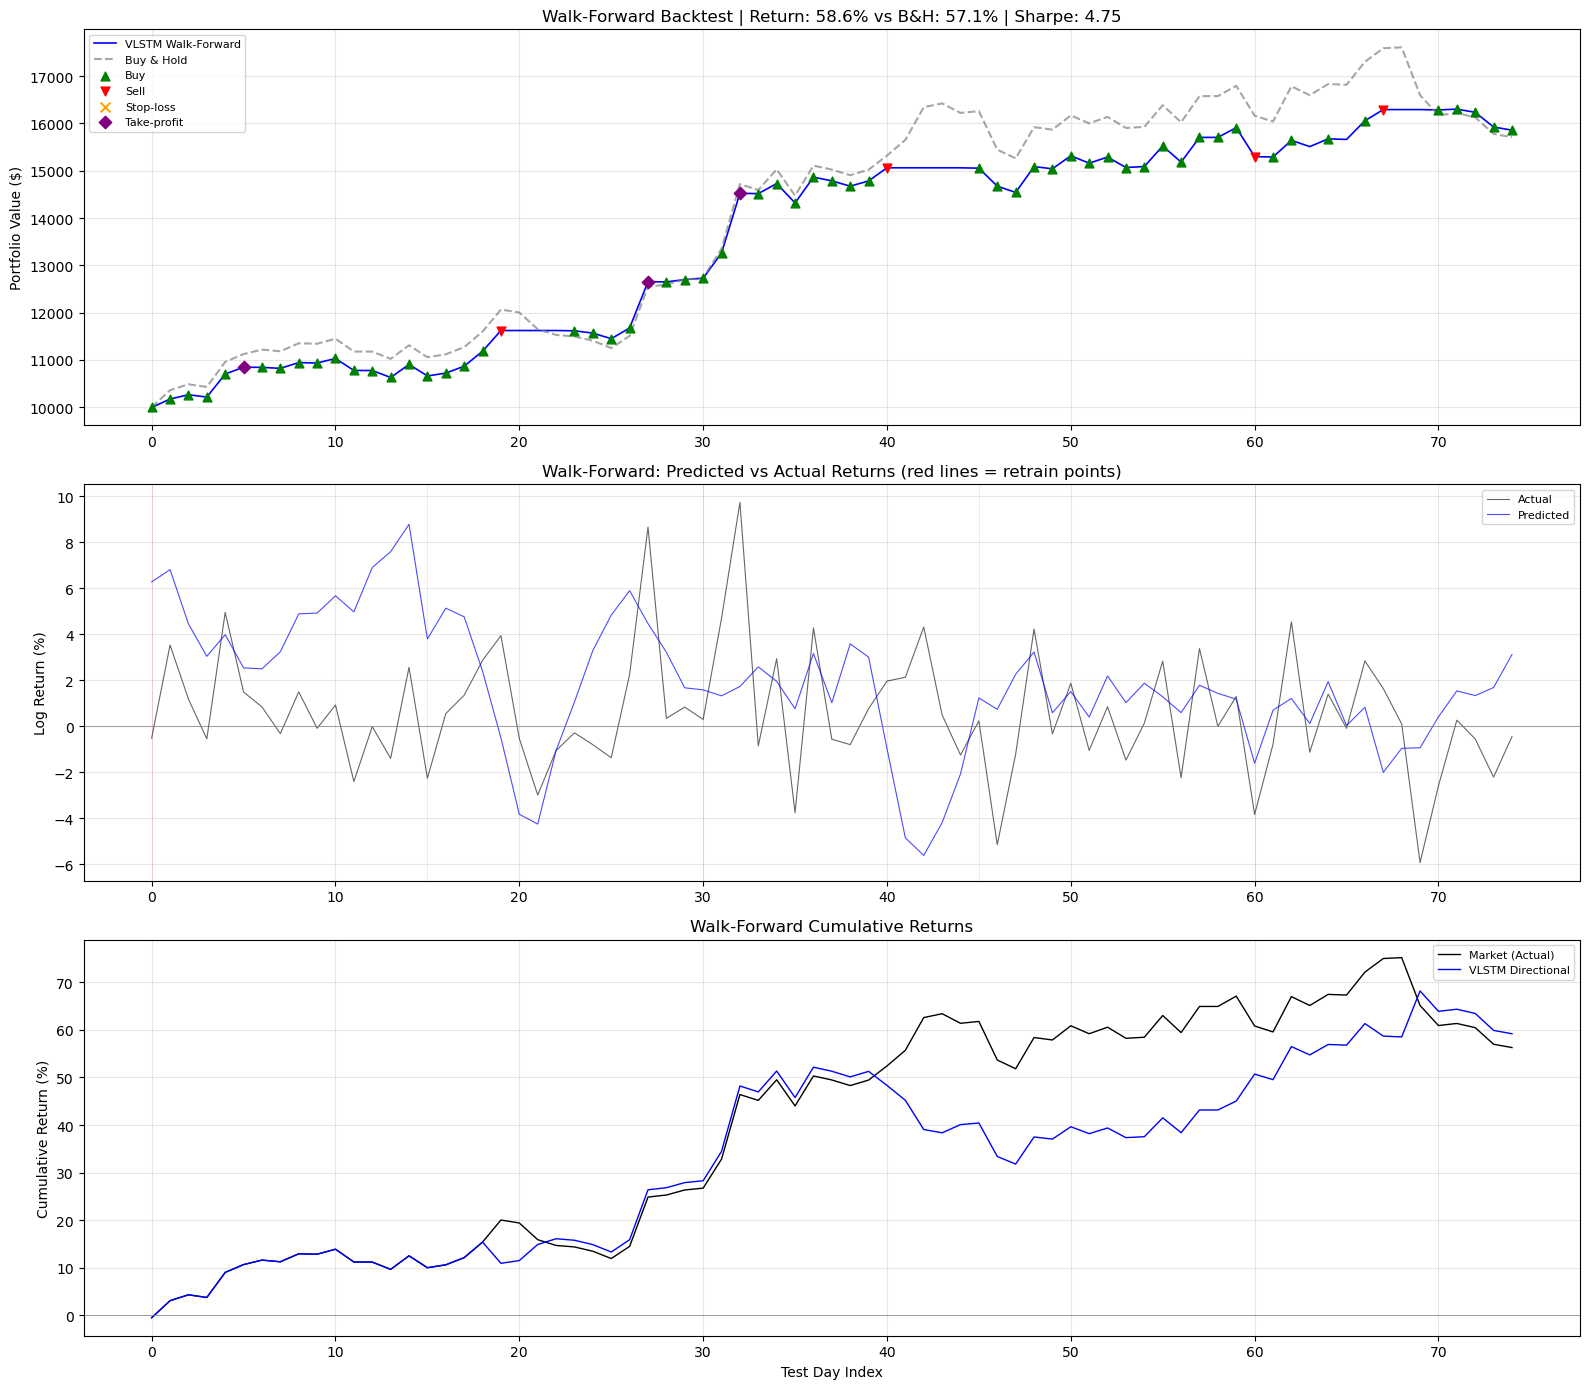

In [67]:
# ── Walk-Forward Visualization ──

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# 1. Portfolio vs Buy & Hold
ax = axes[0]
ax.plot(wf_portfolio, label='VLSTM Walk-Forward', color='blue', linewidth=1.2)
bh_line_wf = init_cash * wf_prices / wf_prices[0]
ax.plot(bh_line_wf, label='Buy & Hold', color='gray', linestyle='--', alpha=0.7)
ax.scatter(wf_buy_idx, wf_portfolio[wf_buy_idx], marker='^', color='green', s=40, zorder=5, label='Buy')
ax.scatter(wf_sell_idx, wf_portfolio[wf_sell_idx], marker='v', color='red', s=40, zorder=5, label='Sell')
ax.scatter(wf_stop_idx, wf_portfolio[wf_stop_idx], marker='x', color='orange', s=50, zorder=5, label='Stop-loss')
ax.scatter(wf_tp_idx, wf_portfolio[wf_tp_idx], marker='D', color='purple', s=40, zorder=5, label='Take-profit')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title(f'Walk-Forward Backtest | Return: {wf_model_ret:.1f}% vs B&H: {wf_bh_ret:.1f}% | Sharpe: {wf_sharpe:.2f}')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# 2. Predicted vs Actual returns
ax = axes[1]
ax.plot(wf_actual_returns * 100, label='Actual', color='black', alpha=0.6, linewidth=0.8)
ax.plot(wf_pred_returns * 100, label='Predicted', color='blue', alpha=0.7, linewidth=0.8)
ax.axhline(0, color='gray', linewidth=0.5)
# Mark window boundaries
for w in range(0, len(wf_pred_returns), STEP_SIZE):
    ax.axvline(w, color='red', alpha=0.15, linewidth=0.5)
ax.set_ylabel('Log Return (%)')
ax.set_title('Walk-Forward: Predicted vs Actual Returns (red lines = retrain points)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Cumulative returns
ax = axes[2]
cum_actual_wf = np.exp(np.cumsum(wf_actual_returns)) - 1
cum_dir_wf = np.exp(np.cumsum(wf_actual_returns * np.sign(wf_pred_returns))) - 1
ax.plot(cum_actual_wf * 100, label='Market (Actual)', color='black', linewidth=1)
ax.plot(cum_dir_wf * 100, label='VLSTM Directional', color='blue', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Test Day Index')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Walk-Forward Cumulative Returns')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()